In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

try:
    from skopt import gp_minimize
    from skopt.space import Integer, Real
    print("Bayesian Optimization libraries (skopt) ready.")
except ImportError:
    print("Installing missing dependencies: scikit-optimize...")
    import subprocess
    import sys
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
        from skopt import gp_minimize
        from skopt.space import Integer, Real
        print("scikit-optimize installed and imported.")
    except:
        print("Could not install skopt. Bayesian strategies will fall back to static parameters.")

print("Libraries imported successfully!")

Bayesian Optimization libraries (skopt) ready.
Libraries imported successfully!


In [2]:
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


In [3]:
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


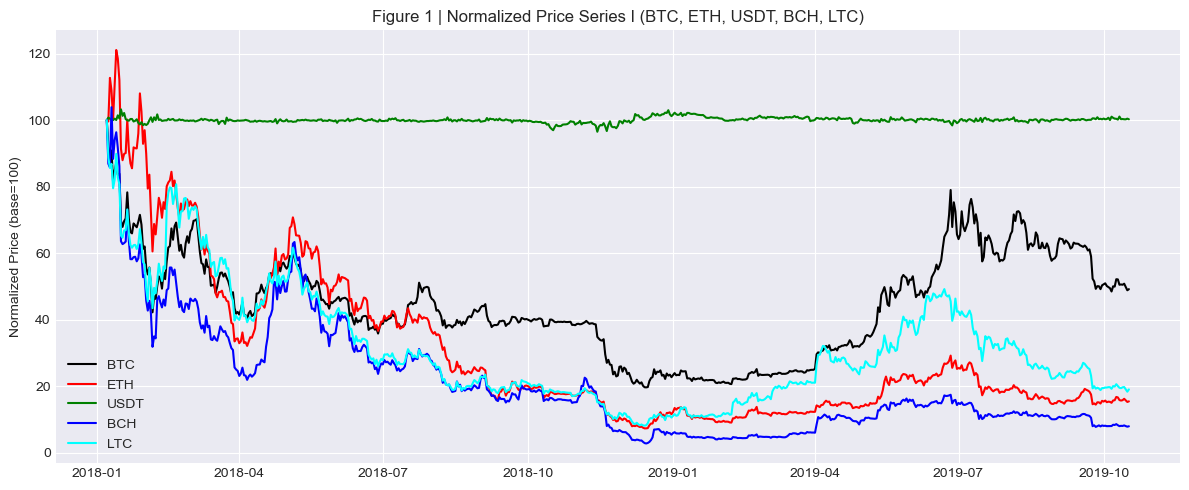

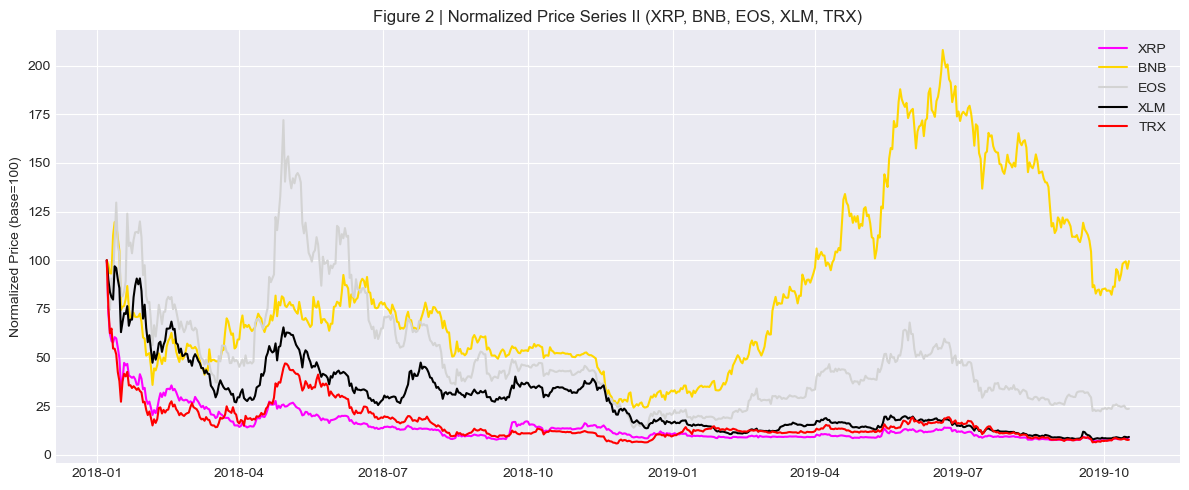

In [4]:
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col],
             label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col],
             label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

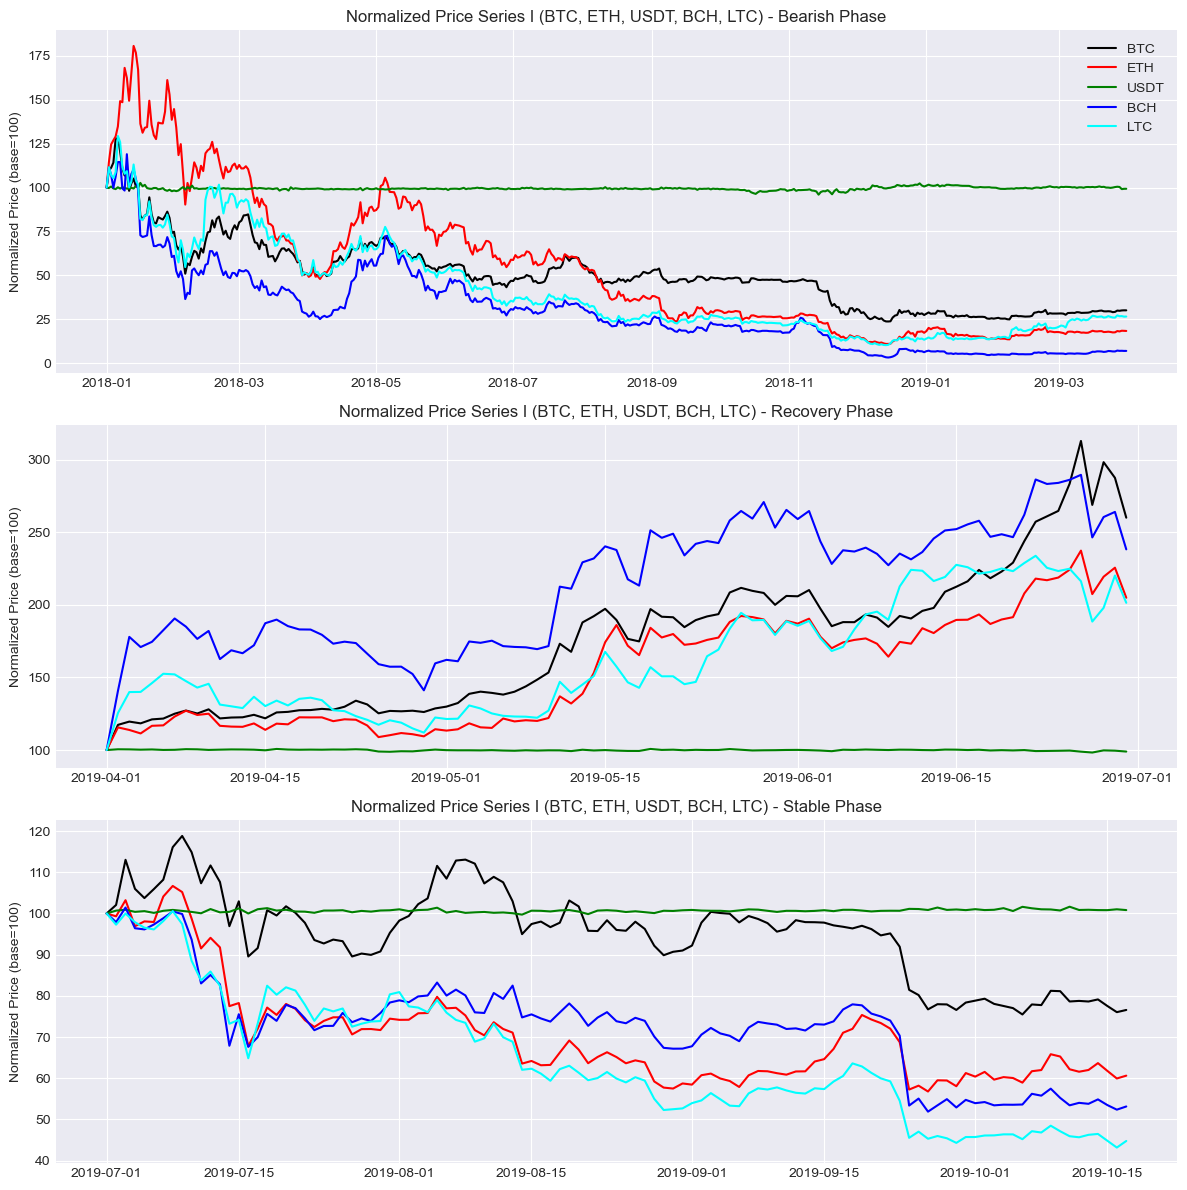

In [5]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for idx, (fase_name, (start_date, end_date)) in enumerate(fase_pasar.items()):
    ax = axes[idx]
    
    # Slice the price data for the current phase
    # Finding the actual start date available in the index that is >= start_date
    mask = (df_prices.index >= start_date) & (df_prices.index <= end_date)
    df_phase = df_prices.loc[mask, assets_1]
    
    if len(df_phase) > 0:
        # Normalize to base=100 at the beginning of the phase
        df_norm_phase = (df_phase / df_phase.iloc[0]) * 100
        
        for i, col in enumerate(df_norm_phase.columns):
            ax.plot(df_norm_phase.index, df_norm_phase[col], label=col, color=colors_1[i])
            
    ax.set_title(f'Normalized Price Series I (BTC, ETH, USDT, BCH, LTC) - {fase_name} Phase')
    ax.set_ylabel('Normalized Price (base=100)')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

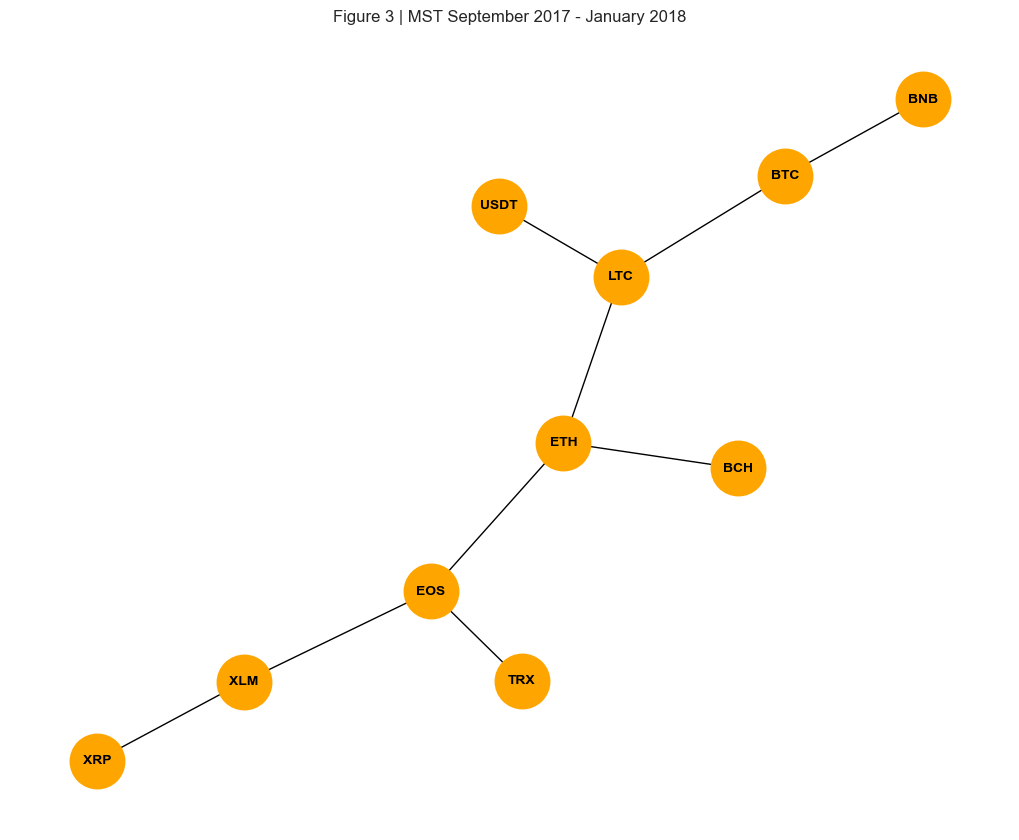

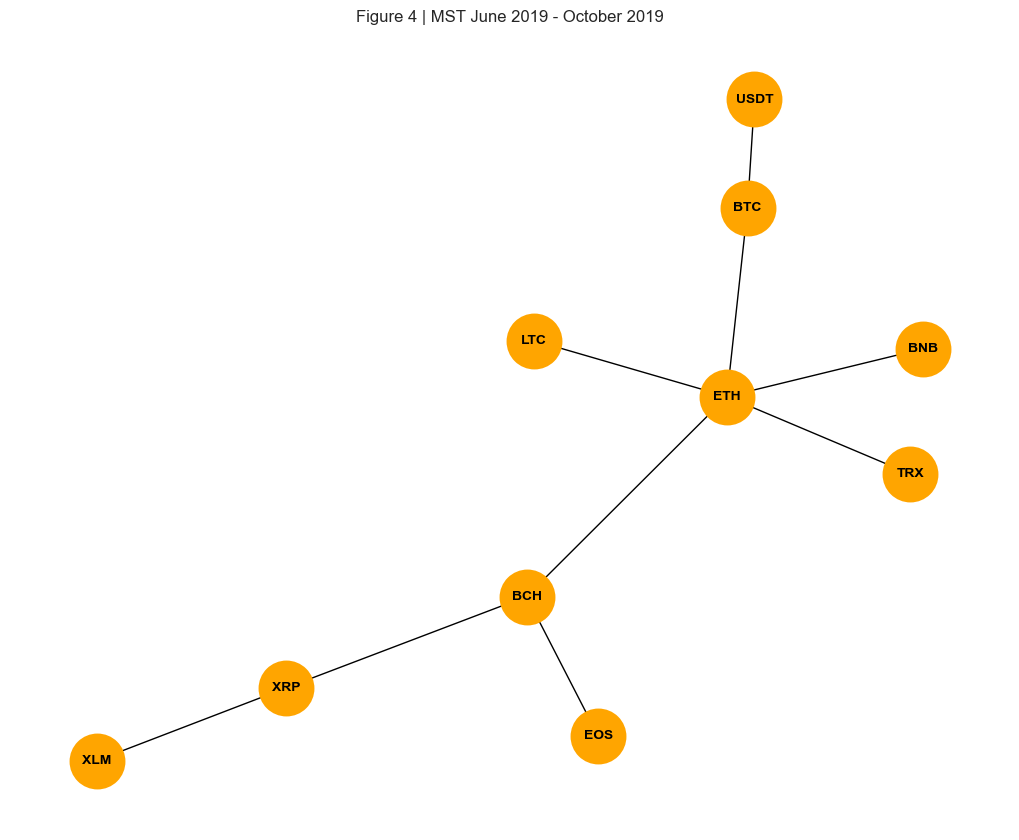

In [6]:
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

In [7]:
def apply_rmt_filter(returns_data):
    """
    Apply Random Matrix Theory filter to the correlation matrix.
    """
    if returns_data.shape[1] < 2:
        return np.atleast_2d(np.array([1.0]))
        
    T, N = returns_data.shape
    Q = T / N
    C = np.atleast_2d(np.corrcoef(returns_data.T))
    
    eigenvalues, eigenvectors = eigsh(C, k=N-1) if N > 10 else np.linalg.eigh(C)
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues_filtered = np.where(eigenvalues > lambda_max, eigenvalues, 0)
    
    sum_filtered = np.sum(eigenvalues) - np.sum(eigenvalues_filtered)
    count_filtered = N - np.count_nonzero(eigenvalues_filtered)
    if count_filtered > 0:
        avg_noise = sum_filtered / count_filtered
        eigenvalues_filtered[eigenvalues_filtered == 0] = avg_noise
    
    C_filtered = eigenvectors @ np.diag(eigenvalues_filtered) @ eigenvectors.T
    np.fill_diagonal(C_filtered, 1)
    return C_filtered

def build_mst(correlation_matrix):
    """
    Build Minimum Spanning Tree from correlation matrix.
    """
    # Convert correlation to distance matrix: d = sqrt(2*(1-rho))
    distance_matrix = np.sqrt(2 * (1 - np.clip(correlation_matrix, -1, 1)))
    G = nx.from_numpy_array(distance_matrix)
    mst = nx.minimum_spanning_tree(G)
    return nx.to_numpy_array(mst)

def compute_eigenvector_centrality(distance_matrix):
    """
    Compute eigenvector centrality from a distance/adjacency matrix.
    """
    G = nx.from_numpy_array(distance_matrix)
    try:
        centrality = nx.eigenvector_centrality_numpy(G)
        # Convert dict to array matched with node order
        return np.array([centrality[i] for i in range(len(centrality))])
    except:
        # Fallback to degree centrality if it fails to converge
        centrality = nx.degree_centrality(G)
        return np.array([centrality[i] for i in range(len(centrality))])


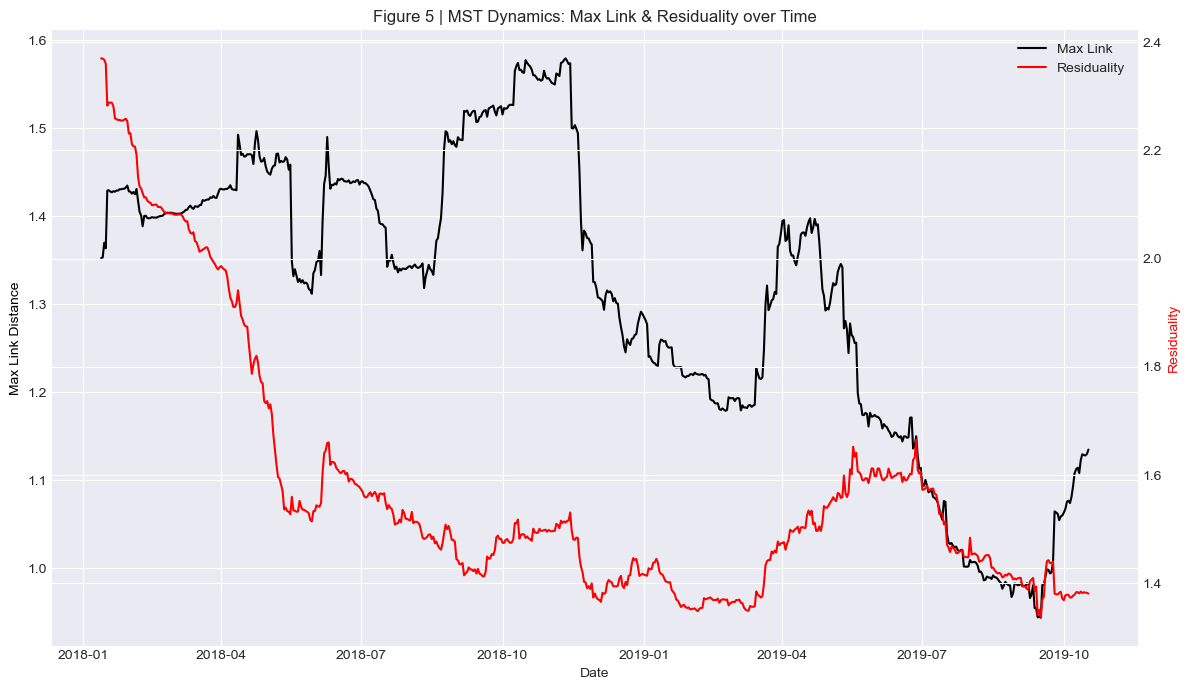

In [8]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates          = returns_df.index[window:]
    max_links      = []
    residualities  = []
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(
            np.sum(mst_weights) / (returns_df.shape[1] - 1)
        )
    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )

mst_dyn = calculate_rolling_mst_metrics(df_returns)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'],
         color='black', label='Max Link')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'],
         color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time')
plt.tight_layout()
plt.show()

In [9]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
    def get_weights(self, returns_data):
        raise NotImplementedError

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


class MISNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0, window_size=24, correlation_threshold=0.4):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.correlation_threshold = correlation_threshold
        self.param_history = []

    def get_weights(self, returns_data):
        # 1. Filter aset menggunakan MIS
        selected_assets = get_assets_graph_diversify_rmt(returns_data, self.correlation_threshold)
        sub_data = returns_data[selected_assets]
        
        # Simpan histori parameter untuk analisis
        self.param_history.append({
            'window': self.window_size,
            'gamma': self.gamma,
            'threshold': self.correlation_threshold,
            'num_assets': len(selected_assets)
        })

        # Fallback: Jika aset terlalu sedikit (< 2), gunakan Equal Weighting pada subset atau full universe
        if len(selected_assets) < 2:
            n_all = returns_data.shape[1]
            return np.ones(n_all) / n_all

        # 2. Network Markowitz Optimization pada subset
        N = sub_data.shape[1]
        mu = sub_data.mean().values
        sig = sub_data.std().values
        Cf = apply_rmt_filter(sub_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        
        # Centrality modification
        cent_mod = (1 + cent)**self.gamma
        sig_adj = sig * cent_mod
        
        # Optimization
        w = cp.Variable(N)
        ret = mu @ w
        risk = cp.norm(np.diag(sig_adj) @ w, 2)
        
        prob = cp.Problem(cp.Maximize(ret - 0.5 * risk), 
                          [cp.sum(w) == 1, w >= 0])
        
        try:
            prob.solve(solver=cp.ECOS)
            if w.value is None: raise ValueError
            weights_subset = w.value
        except:
            weights_subset = np.ones(N) / N

        # 3. Map kembali ke full asset universe
        full_weights = np.zeros(returns_data.shape[1])
        for i, asset in enumerate(selected_assets):
            idx = returns_data.columns.get_loc(asset)
            full_weights[idx] = weights_subset[i]
            
        return full_weights



In [10]:
# BayesianNW class removed - Grid Search is applied statically in the tuning cell


In [11]:

def backtest_strategy(strategy, df_returns,
                      rebalance_freq=7,
                      transaction_cost=0.001,
                      global_start=None):
    """
    Simulasi backtesting dengan rolling window.
    
    Fair comparison: semua strategi mulai dari indeks yang sama (global_start),
    meskipun masing-masing strategi hanya menggunakan data sebesar window_size-nya
    sendiri untuk training.
    """
    window_size  = strategy.window_size
    start_idx    = global_start if global_start is not None else window_size
    portfolio_returns = []
    dates             = []
    
    for i in range(start_idx, len(df_returns), rebalance_freq):
        train_start = max(0, i - window_size)
        train       = df_returns.iloc[train_start:i]
        w           = strategy.get_weights(train)
        test_end    = min(i + rebalance_freq, len(df_returns))
        test_data   = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates,
                           'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()
    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }

print("Backtest function defined!")

Backtest function defined!


In [12]:
# --- STATIC PARAMETERS (Optimized Values) ---
tuned_params = {
    'VAR':    {'W': 33, 'G': 0.7},
    'SHARPE': {'W': 25, 'G': 0.4},
    'RACHEV': {'W': 25, 'G': 0.4},
    'MDD':    {'W': 24, 'G': 1.0},
    'RETURN': {'W': 25, 'G': 0.4}
}
print('Using static optimized parameters for all strategies.')


Using static optimized parameters for all strategies.


In [13]:
strategies = [
    EquallyWeighted('Equal Weighted'),

    # --- Baseline: NW Tuned (parameter statis per metrik) ---
    NetworkMarkowitz(f"NW Tuned (VAR: W={tuned_params['VAR']['W']}, G={tuned_params['VAR']['G']})",
                     gamma=tuned_params['VAR']['G'], window_size=tuned_params['VAR']['W']),
    NetworkMarkowitz(f"NW Tuned (Sharpe: W={tuned_params['SHARPE']['W']}, G={tuned_params['SHARPE']['G']})",
                     gamma=tuned_params['SHARPE']['G'], window_size=tuned_params['SHARPE']['W']),
    NetworkMarkowitz(f"NW Tuned (Rachev: W={tuned_params['RACHEV']['W']}, G={tuned_params['RACHEV']['G']})",
                     gamma=tuned_params['RACHEV']['G'], window_size=tuned_params['RACHEV']['W']),
    NetworkMarkowitz(f"NW Tuned (MDD: W={tuned_params['MDD']['W']}, G={tuned_params['MDD']['G']})",
                     gamma=tuned_params['MDD']['G'], window_size=tuned_params['MDD']['W']),
    NetworkMarkowitz(f"NW Tuned (Return: W={tuned_params['RETURN']['W']}, G={tuned_params['RETURN']['G']})",
                     gamma=tuned_params['RETURN']['G'], window_size=tuned_params['RETURN']['W']),

    # --- NOVELTY: Two-Stage MIS + NW (Hybrid) ---
    # Menggunakan parameter MDD terbaik (W=24, G=1.0):
    # Stage 1: MIS filter pada threshold=0.4 -> subset aset independen
    # Stage 2: Full NW (RMT + MST + Centrality) pada subset tersebut
    MISNetworkMarkowitz(
        'MIS-NW Hybrid (W=24, G=1.0, thr=0.4)',
        gamma=tuned_params['MDD']['G'],
        window_size=tuned_params['MDD']['W'],
        correlation_threshold=0.4
    ),
]


In [14]:
results = {}
print(f'Memulai backtest untuk {len(strategies)} strategi...')
for strat in strategies:
    print(f'Running: {strat.name} ...')
    results[strat.name] = backtest_strategy(strat, df_returns, global_start=120)
print('\nBacktest Selesai!')


Memulai backtest untuk 7 strategi...
Running: Equal Weighted ...
Running: NW Tuned (VAR: W=33, G=0.7) ...
Running: NW Tuned (Sharpe: W=25, G=0.4) ...
Running: NW Tuned (Rachev: W=25, G=0.4) ...
Running: NW Tuned (MDD: W=24, G=1.0) ...
Running: NW Tuned (Return: W=25, G=0.4) ...
Running: MIS-NW Hybrid (W=24, G=1.0, thr=0.4) ...


NameError: name 'get_assets_graph_diversify_rmt' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def show_bayesian_results(strat_name):
    strat = next((s for s in strategies if s.name == strat_name), None)
    if not strat or not strat.param_history:
        print(f"Data untuk {strat_name} tidak ditemukan atau backtest belum dijalankan.")
        return
    
    df = pd.DataFrame(strat.param_history)
    print(f"\n{'='*50}\nParameter Optimal: {strat_name}\n{'='*50}")
    print(df.tail(10).to_string(index=False))
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    ax1.plot(df['date'], df['window'], 'g-', label='Window Size')
    ax2.plot(df['date'], df['gamma'], 'b-', label='Gamma (Penalty)')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Window', color='g')
    ax2.set_ylabel('Gamma', color='b')
    plt.title(f'Evolusi Parameter Adaptive {strat_name}')
    plt.show()

show_bayesian_results('NW Bayesian (VAR)')
show_bayesian_results('NW Bayesian (Sharpe)')


Data untuk NW Bayesian (VAR) tidak ditemukan atau backtest belum dijalankan.
Data untuk NW Bayesian (Sharpe) tidak ditemukan atau backtest belum dijalankan.


In [ ]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w = strat.window_size
        avg_g = strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = '-'
        
    row['Window'] = f"{avg_w:.0f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['Gamma'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g

    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.rename(columns={
    '2018-01-31': 'Jan-2018', '2018-05-31': 'May-2018', '2018-09-30': 'Sep-2018',
    '2019-01-31': 'Jan-2019', '2019-05-31': 'May-2019', '2019-09-30': 'Sep-2019'
}, inplace=True)

print("TABLE 2 | Cumulative Profits and Losses (%) with Parameters")
display(table2)

TABLE 2 | Cumulative Profits and Losses (%) with Parameters


,Window,Gamma,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
Equal Weighted,120,-,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
"NW Tuned (VAR: W=33, G=0.7)",33,0.70,-29.30,-37.39,-40.22,-39.03,5.68,2.36
"NW Tuned (Sharpe: W=25, G=0.4)",25,0.40,-20.17,-26.99,-29.97,-28.32,39.78,32.74
"NW Tuned (Rachev: W=25, G=0.4)",25,0.40,-20.17,-26.99,-29.97,-28.32,39.78,32.74
"NW Tuned (MDD: W=24, G=1.0)",24,1.00,-16.83,-20.50,-24.00,-22.32,52.47,27.84
"NW Tuned (Return: W=25, G=0.4)",25,0.40,-20.17,-26.99,-29.97,-28.32,39.78,32.74
"MIS-NW Hybrid (W=24, G=1.0, thr=0.4)",24,1.00,-35.65,3.04,-24.41,-38.15,36.98,-43.41


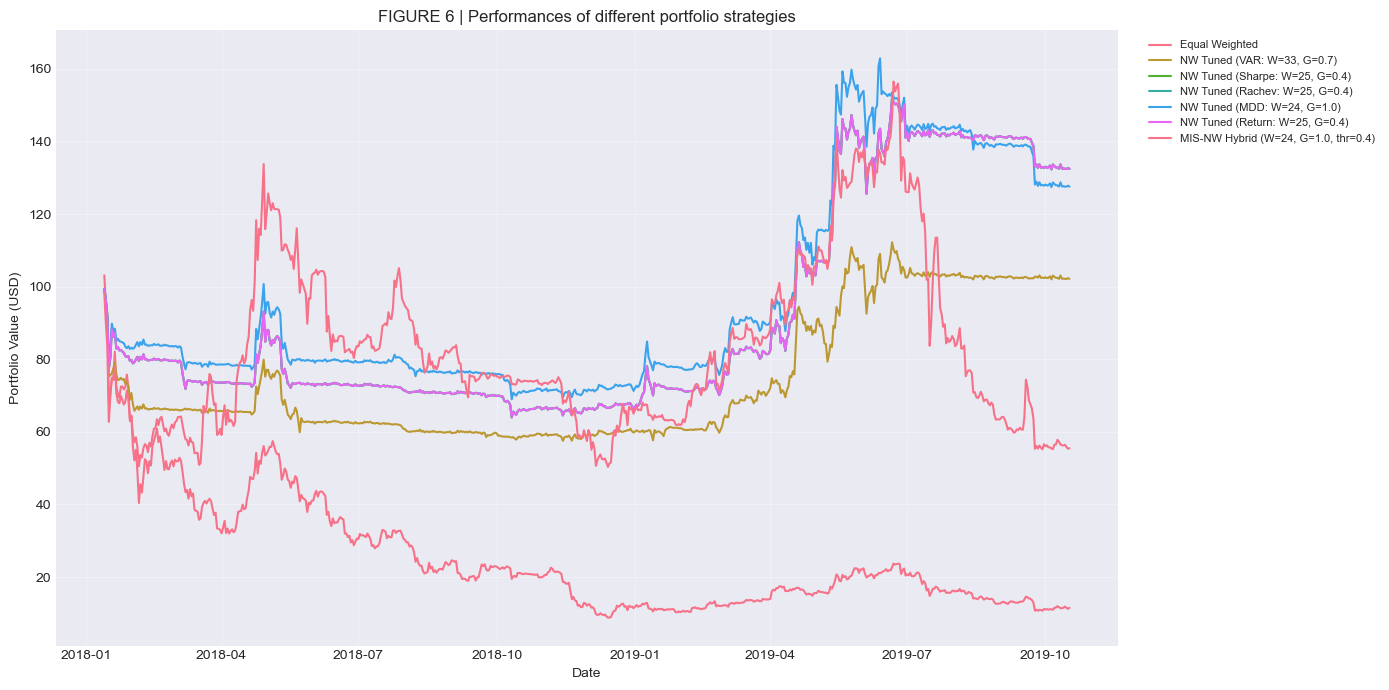

In [ ]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)
plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
period_ranges = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[period_label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
display(table3)

TABLE 3 | VaR 95% (4-month window, scaled x100)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
Equal Weighted,120.0,-,13.7904,9.5511,6.5477,9.4876,3.6840,8.2085
"NW Tuned (VAR: W=33, G=0.7)",33.0,0.70,6.5951,2.8816,0.7667,1.1674,2.4558,1.8905
"NW Tuned (Sharpe: W=25, G=0.4)",25.0,0.40,6.3113,2.8039,0.6978,1.5677,2.4755,2.0084
"NW Tuned (Rachev: W=25, G=0.4)",25.0,0.40,6.3113,2.8039,0.6978,1.5677,2.4755,2.0084
"NW Tuned (MDD: W=24, G=1.0)",24.0,1.00,5.7014,2.5876,0.7694,1.5621,2.5921,2.8541
"NW Tuned (Return: W=25, G=0.4)",25.0,0.40,6.3113,2.8039,0.6978,1.5677,2.4755,2.0084
"MIS-NW Hybrid (W=24, G=1.0, thr=0.4)",24.0,1.00,10.8607,8.0220,4.9077,4.2447,3.9844,8.7706


In [ ]:
table4_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[period_label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
display(table4)

TABLE 4 | Sharpe Ratio (4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
Equal Weighted,120.0,-,-0.2532,-0.0425,-0.0986,-0.1270,0.2016,-0.1298
"NW Tuned (VAR: W=33, G=0.7)",33.0,0.70,-0.3728,-0.0415,-0.0913,0.0233,0.1998,-0.0080
"NW Tuned (Sharpe: W=25, G=0.4)",25.0,0.40,-0.2384,-0.0270,-0.0923,0.0211,0.2091,-0.0204
"NW Tuned (Rachev: W=25, G=0.4)",25.0,0.40,-0.2384,-0.0270,-0.0923,0.0211,0.2091,-0.0204
"NW Tuned (MDD: W=24, G=1.0)",24.0,1.00,-0.2239,-0.0086,-0.0707,0.0205,0.2047,-0.0790
"NW Tuned (Return: W=25, G=0.4)",25.0,0.40,-0.2384,-0.0270,-0.0923,0.0211,0.2091,-0.0204
"MIS-NW Hybrid (W=24, G=1.0, thr=0.4)",24.0,1.00,-0.2630,0.1006,-0.0792,-0.0483,0.2201,-0.1469


In [ ]:
table5_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[period_label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
display(table5)

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
Equal Weighted,120.0,-,0.3926,0.8889,0.8062,0.7200,1.7430,0.5381
"NW Tuned (VAR: W=33, G=0.7)",33.0,0.70,0.1967,0.9248,0.7264,1.1274,2.0829,0.9205
"NW Tuned (Sharpe: W=25, G=0.4)",25.0,0.40,0.6665,0.9812,0.8025,1.1438,2.6708,0.8565
"NW Tuned (Rachev: W=25, G=0.4)",25.0,0.40,0.6665,0.9812,0.8025,1.1438,2.6708,0.8565
"NW Tuned (MDD: W=24, G=1.0)",24.0,1.00,0.6670,1.0677,0.8798,1.1275,2.5135,0.6900
"NW Tuned (Return: W=25, G=0.4)",25.0,0.40,0.6665,0.9812,0.8025,1.1438,2.6708,0.8565
"MIS-NW Hybrid (W=24, G=1.0, thr=0.4)",24.0,1.00,0.5430,1.2316,0.8370,0.9720,1.5356,0.7091


In [ ]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

sharpe_rows = []
rachev_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    sr_row = {'Strategy': strat_name}
    sr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    sr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    sr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    sr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    rr_row = {'Strategy': strat_name}
    rr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    rr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    rr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    rr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        sr_row[fase] = round(sr, 4)
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        rr_row[fase] = round(rr, 4)
    sharpe_rows.append(sr_row)
    rachev_rows.append(rr_row)

table6_sharpe = pd.DataFrame(sharpe_rows).set_index('Strategy')
table6_rachev = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
display(table6_sharpe)
print("\nPanel B: Rachev Ratio (alpha=10%)")
display(table6_rachev)

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
Equal Weighted,120.0,-,-0.0726,0.1286,-0.1301
"NW Tuned (VAR: W=33, G=0.7)",33.0,0.70,-0.0399,0.1411,-0.0048
"NW Tuned (Sharpe: W=25, G=0.4)",25.0,0.40,-0.0195,0.1892,-0.0877
"NW Tuned (Rachev: W=25, G=0.4)",25.0,0.40,-0.0195,0.1892,-0.0877
"NW Tuned (MDD: W=24, G=1.0)",24.0,1.00,-0.0072,0.1587,-0.1220
"NW Tuned (Return: W=25, G=0.4)",25.0,0.40,-0.0195,0.1892,-0.0877
"MIS-NW Hybrid (W=24, G=1.0, thr=0.4)",24.0,1.00,0.0118,0.1309,-0.1624



Panel B: Rachev Ratio (alpha=10%)


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
Equal Weighted,120.0,-,0.7933,1.2168,0.5712
"NW Tuned (VAR: W=33, G=0.7)",33.0,0.70,0.8384,1.4920,1.1048
"NW Tuned (Sharpe: W=25, G=0.4)",25.0,0.40,0.9835,1.9271,0.7771
"NW Tuned (Rachev: W=25, G=0.4)",25.0,0.40,0.9835,1.9271,0.7771
"NW Tuned (MDD: W=24, G=1.0)",24.0,1.00,1.0451,1.8181,0.6279
"NW Tuned (Return: W=25, G=0.4)",25.0,0.40,0.9835,1.9271,0.7771
"MIS-NW Hybrid (W=24, G=1.0, thr=0.4)",24.0,1.00,1.0273,1.2647,0.6755


In [ ]:
# Bayesian parameter evolution plot removed (not applicable for static Grid Search tuning)


In [ ]:
# Bayesian parameter summary removed (not applicable for static Grid Search tuning)
print("Grid Search Tuned Parameters:")
for metric, params in tuned_params.items():
    print(f"  {metric}: W={params['W']}, G={params['G']:.1f}")


Grid Search Tuned Parameters:
  VAR: W=33, G=0.7
  SHARPE: W=25, G=0.4
  RACHEV: W=25, G=0.4
  MDD: W=24, G=1.0
  RETURN: W=25, G=0.4


# GRID SEARCH OPTIMIZATION: MIS-NW HYBRID STRATEGY
Melakukan Grid Search 2-level (Coarse & Fine) untuk mengoptimalkan parameter `window_size`, `gamma`, dan `correlation_threshold` pada strategi Hybrid.

In [ ]:
import numpy as np
import pandas as pd
import time

# 1. Definisi Parameter Coarse Grid
coarse_windows = [24, 60, 120]
coarse_gammas  = [0.1, 1.0, 5.0]
coarse_thresholds = [0.2, 0.5, 0.8]

grid_results = []
total_coarse = len(coarse_windows) * len(coarse_gammas) * len(coarse_thresholds)
counter = 0

print(f"Memulai Coarse Grid Search ({total_coarse} kombinasi)...")

for w in coarse_windows:
    for g in coarse_gammas:
        for t in coarse_thresholds:
            counter += 1
            strat = MISNetworkMarkowitz(name=f\"Hybrid_W{w}_G{g}_T{t}\", 
                                       window_size=w, gamma=g, correlation_threshold=t)
            
            # Backtest singkat (global_start=120 sesuai baseline)
            res = backtest_strategy(strat, df_returns, global_start=120)
            df_res = res['results_df']
            segment = df_res['return'].dropna().values
            
            if len(segment) > 0:
                var_val    = abs(calculate_var(segment, 0.95)) * 100
                tot_ret    = (df_res['cumulative_return'].iloc[-1] - 1) * 100
                rachev_val = calculate_rachev_ratio(segment, 0.10)
                sharpe_val = np.mean(segment) / np.std(segment) if np.std(segment) > 1e-6 else 0
                
                grid_results.append({
                    'W': w, 'G': g, 'T': t,
                    'VaR': var_val, 'Return': tot_ret, 'Rachev': rachev_val, 'Sharpe': sharpe_val
                })
            
            if counter % 5 == 0: print(f\"Progress: {counter}/{total_coarse} selesai.\")

coarse_df = pd.DataFrame(grid_results)

# 2. Identifikasi Best Candidate
best_by_metric = {
    'VaR':    coarse_df.loc[coarse_df['VaR'].idxmin()], 
    'Return': coarse_df.loc[coarse_df['Return'].idxmax()],
    'Rachev': coarse_df.loc[coarse_df['Rachev'].idxmax()],
    'Sharpe': coarse_df.loc[coarse_df['Sharpe'].idxmax()]
}

print("\\nBest Parameters from Coarse Search:")
for m, row in best_by_metric.items():
    print(f"  {m}: W={row['W']}, G={row['G']}, T={row['T']} | Value: {row[m]:.4f}")

# 3. Fine Grid Search disekitar Best Sharpe
best_w, best_g, best_t = best_by_metric['Sharpe']['W'], best_by_metric['Sharpe']['G'], best_by_metric['Sharpe']['T']
fine_windows = [max(12, int(best_w*0.8)), int(best_w), int(best_w*1.2)]
fine_gammas  = [max(0.1, best_g-0.2), best_g, best_g+0.2]
fine_thresholds = [max(0.1, best_t-0.1), best_t, min(0.9, best_t+0.1)]

print(f"\\nMemulai Fine Grid Search disekitar Best Sharpe...")
for w in set(fine_windows):
    for g in set(fine_gammas):
        for t in set(fine_thresholds):
            strat = MISNetworkMarkowitz(name=f\"Fine_W{w}_G{g}_T{t}\", 
                                       window_size=w, gamma=g, correlation_threshold=t)
            res = backtest_strategy(strat, df_returns, global_start=120)
            df_res = res['results_df']
            segment = df_res['return'].dropna().values
            
            if len(segment) > 0:
                grid_results.append({
                    'W': w, 'G': g, 'T': t,
                    'VaR': abs(calculate_var(segment, 0.95)) * 100,
                    'Return': (df_res['cumulative_return'].iloc[-1] - 1) * 100,
                    'Rachev': calculate_rachev_ratio(segment, 0.10),
                    'Sharpe': np.mean(segment) / np.std(segment) if np.std(segment) > 1e-6 else 0
                })

full_grid_df = pd.DataFrame(grid_results)
final_best_sharpe = full_grid_df.loc[full_grid_df['Sharpe'].idxmax()]
final_best_return = full_grid_df.loc[full_grid_df['Return'].idxmax()]
final_best_var    = full_grid_df.loc[full_grid_df['VaR'].idxmin()]
final_best_rachev = full_grid_df.loc[full_grid_df['Rachev'].idxmax()]

print("\\nFINAL OPTIMIZED PARAMETERS for MIS-NW Hybrid:")
print(f"  Best Sharpe: W={final_best_sharpe['W']}, G={final_best_sharpe['G']:.2f}, T={final_best_sharpe['T']:.2f}")
print(f"  Best Return: W={final_best_return['W']}, G={final_best_return['G']:.2f}, T={final_best_return['T']:.2f}")
print(f"  Best VaR   : W={final_best_var['W']}, G={final_best_var['G']:.2f}, T={final_best_var['T']:.2f}")
print(f"  Best Rachev: W={final_best_rachev['W']}, G={final_best_rachev['G']:.2f}, T={final_best_rachev['T']:.2f}")

final_hybrid_strat = MISNetworkMarkowitz(
    name=f\"MIS-NW Hybrid (Optimized)\", 
    window_size=int(final_best_sharpe['W']), 
    gamma=final_best_sharpe['G'], 
    correlation_threshold=final_best_sharpe['T']
)
results[final_hybrid_strat.name] = backtest_strategy(final_hybrid_strat, df_returns, global_start=120)
if final_hybrid_strat not in strategies: strategies.append(final_hybrid_strat)


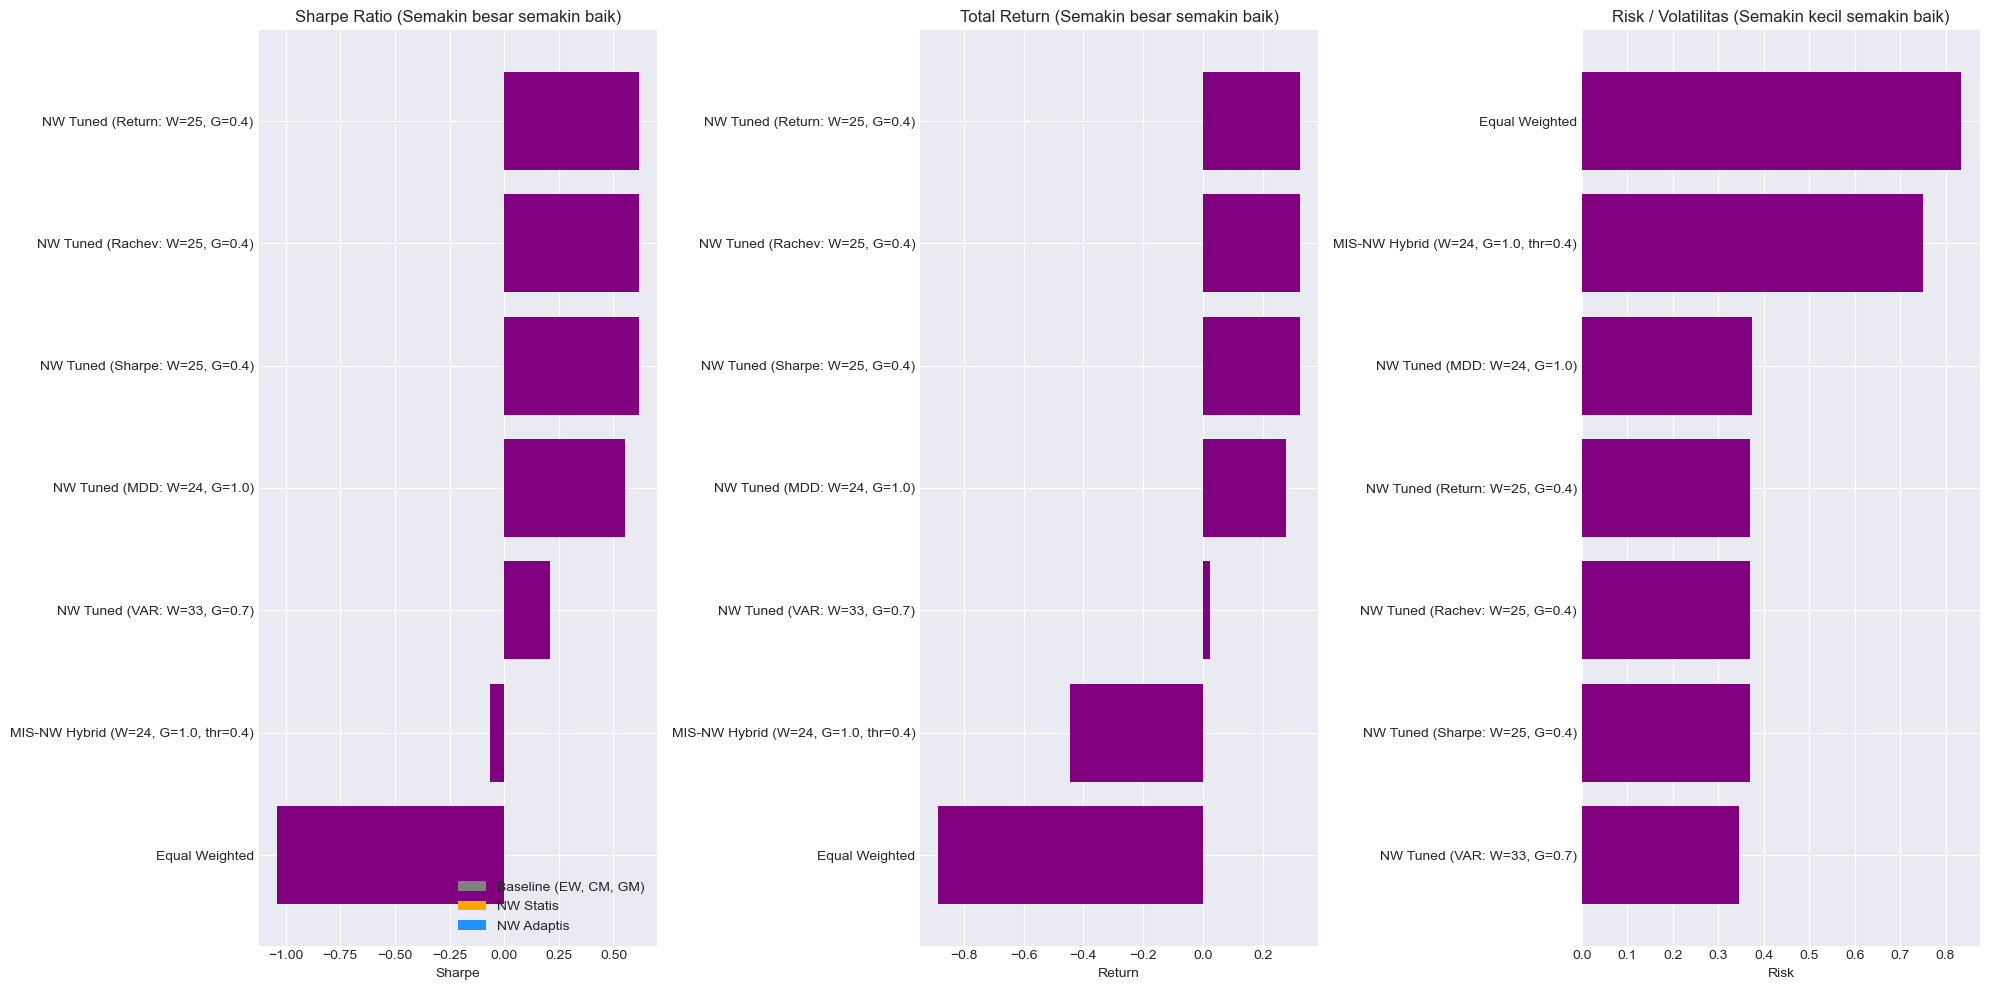

In [ ]:
import numpy as np

data_rows = []
for strat_name, res in results.items():
    df_res = res['results_df']
    returns = df_res['return'].dropna().values
    
    if len(returns) > 0:
        tot_ret = np.prod(1 + returns) - 1 # or np.sum(returns) if log returns
        risk = np.std(returns) * np.sqrt(365) # annualized volatility
        sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(365) if np.std(returns) > 1e-6 else 0
    else:
        tot_ret, risk, sharpe = 0, 0, 0
        
    data_rows.append({'Strategy': strat_name, 'Return': tot_ret, 'Risk': risk, 'Sharpe': sharpe})

comparison = pd.DataFrame(data_rows).set_index('Strategy')

def get_color(strategy_name):
    if strategy_name in ['EW', 'CM', 'CM 30', 'GM'] or 'Static' not in strategy_name and 'gamma=0' in strategy_name:
        return 'gray'
    elif 'NW Static' in strategy_name or '(gamma' in strategy_name:
        return 'orange' # Static NW
    elif 'Adaptis' in strategy_name or 'GS' in strategy_name:
        return 'dodgerblue' # Adaptive NW
    else:
        return 'purple'

colors = [get_color(idx) for idx in comparison.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

df_sharpe = comparison['Sharpe'].sort_values(ascending=True)
c_sharpe = [get_color(idx) for idx in df_sharpe.index]
axes[0].barh(df_sharpe.index, df_sharpe.values, color=c_sharpe)
axes[0].set_title('Sharpe Ratio (Semakin besar semakin baik)')
axes[0].set_xlabel('Sharpe')

df_return = comparison['Return'].sort_values(ascending=True)
c_return = [get_color(idx) for idx in df_return.index]
axes[1].barh(df_return.index, df_return.values, color=c_return)
axes[1].set_title('Total Return (Semakin besar semakin baik)')
axes[1].set_xlabel('Return')

df_risk = comparison['Risk'].sort_values(ascending=True)
c_risk = [get_color(idx) for idx in df_risk.index]
axes[2].barh(df_risk.index, df_risk.values, color=c_risk)
axes[2].set_title('Risk / Volatilitas (Semakin kecil semakin baik)')
axes[2].set_xlabel('Risk')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', label='Baseline (EW, CM, GM)'),
                   Patch(facecolor='orange', label='NW Statis'),
                   Patch(facecolor='dodgerblue', label='NW Adaptis')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

fig.savefig('horizontal_bar_comparison.png', dpi=300, bbox_inches='tight')
